# Day and Night Image Classifier
---

The day/night image dataset consists of 200 RGB color images in two categories: day and night. There are equal numbers of each example: 100 day images and 100 night images.

We'd like to build a classifier that can accurately label these images as day or night, and that relies on finding distinguishing features between the two types of images!

*Note: All images come from the [AMOS dataset](http://cs.uky.edu/~jacobs/datasets/amos/) (Archive of Many Outdoor Scenes).*

### Solution code

You are encouraged to try to complete this code on your own, but if you are struggling or want to make sure your code is correct, there will be solution code in **the next Notebook: Classification** in the `helpers.py` file. You can jump ahead and look into that python file to see the solution code.

### Import resources

Before you get started on the project code, import the libraries and resources that you'll need.

In [1]:
import cv2 # computer vision library
import matplotlib.image as mpimg
import matplotlib.pyplot as plt
import numpy as np

import helpers

%matplotlib inline

## Training and Testing Data
The 200 day/night images are separated into training and testing datasets. 

* 60% of these images are training images, for you to use as you create a classifier.
* 40% are test images, which will be used to test the accuracy of your classifier.

First, we set some variables to keep track of some where our images are stored:

    image_dir_training: the directory where our training image data is stored
    image_dir_test: the directory where our test image data is stored

In [2]:
IMG = '../../../img'

In [3]:
# Image data directories
image_dir_training = f'{IMG}/day_night/train'
image_dir_test = f'{IMG}/day_night/test'

## Load the datasets

These first few lines of code will load the training day/night images and store all of them in a variable, `IMAGE_LIST`. This list contains the images and their associated label ("day" or "night"). 

For example, the first image-label pair in `IMAGE_LIST` can be accessed by index: 
``` IMAGE_LIST[0][:]```.


In [4]:
IMAGE_LIST = helpers.load_dataset(image_dir_training)
len(IMAGE_LIST)

32

## Construct a `STANDARDIZED_LIST` of input images and output labels.

This function takes in a list of image-label pairs and outputs a **standardized** list of resized images and numerical labels.

In [5]:
STANDARDIZED_LIST = helpers.standardize(IMAGE_LIST)

## Visualize the standardized data

Display a standardized image from STANDARDIZED_LIST.

Shape: (600, 1100, 3)
Label: day


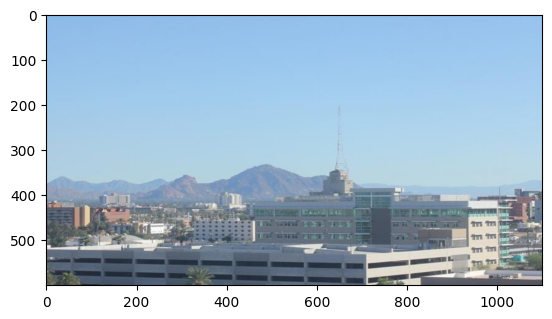

In [7]:
image_num = 0
selected_image = STANDARDIZED_LIST[image_num][0]
selected_label = STANDARDIZED_LIST[image_num][1]
plt.imshow(selected_image)
print(f'Shape: {selected_image.shape}')
print(f'Label: {"day" if selected_label == 1 else "night"}')


# Feature Extraction

Create a feature that represents the brightness in an image. We'll be extracting the **average brightness** using HSV colorspace. Specifically, we'll use the V channel (a measure of brightness), add up the pixel values in the V channel, then divide that sum by the area of the image to get the average Value of the image.


## RGB to HSV conversion

Below, a test image is converted from RGB to HSV colorspace and each component is displayed in an image.

Label: day


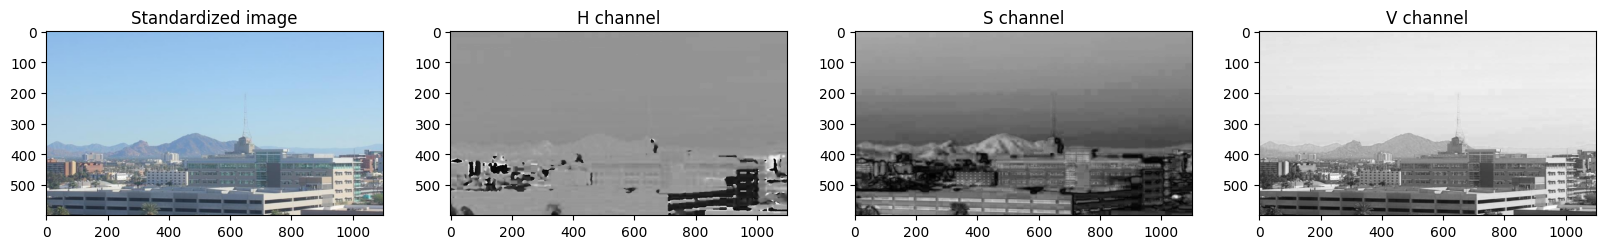

In [9]:
image_num = 0
test_im = STANDARDIZED_LIST[image_num][0]
test_label = STANDARDIZED_LIST[image_num][1]
hsv = cv2.cvtColor(test_im, cv2.COLOR_RGB2HSV)
print(f'Label: {"day" if test_label == 1 else "night"}')

h = hsv[:, :, 0]
s = hsv[:, :, 1]
v = hsv[:, :, 2]

f, (ax1, ax2, ax3, ax4) = plt.subplots(1, 4, figsize=(20, 10))
ax1.set_title('Standardized image')
ax1.imshow(test_im)
ax2.set_title('H channel')
ax2.imshow(h, cmap='gray')
ax3.set_title('S channel')
ax3.imshow(s, cmap='gray')
ax4.set_title('V channel')
ax4.imshow(v, cmap='gray');

---
###  Find the average brightness using the V channel

This function takes in a **standardized** RGB image and returns a feature (a single value) that represent the average level of brightness in the image. We'll use this value to classify the image as day or night.

In [17]:
# Find the average Value or brightness of an image
def avg_brightness(rgb_image):
    hsv = cv2.cvtColor(rgb_image, cv2.COLOR_RGB2HSV)
    sum_brightness = np.sum(hsv[:,:,2])
    n_px = np.prod(rgb_image.shape[:2])
    avg = sum_brightness / n_px
    return avg

Avg brightness: 198.09555757575757


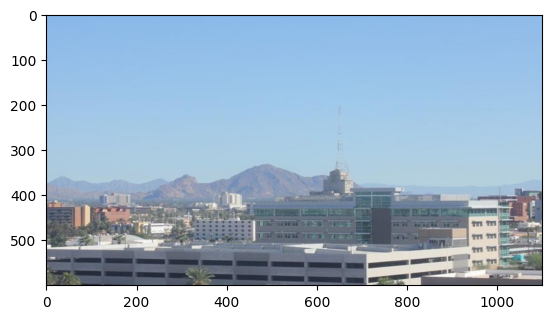

In [18]:
image_num = 1
test_im = STANDARDIZED_LIST[image_num][0]
avg = avg_brightness(test_im)
print(f'Avg brightness: {avg}')
plt.imshow(test_im);

Avg brightness: 47.27310151515152


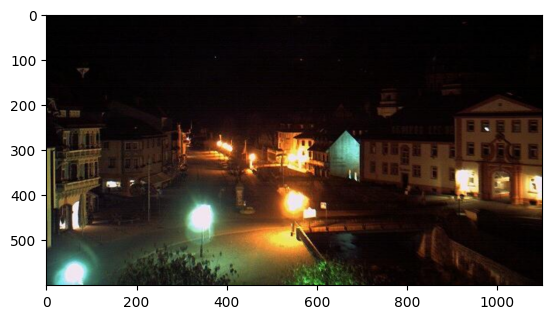

In [19]:
image_num = -1
test_im = STANDARDIZED_LIST[image_num][0]
avg = avg_brightness(test_im)
print(f'Avg brightness: {avg}')
plt.imshow(test_im);